**Загрузка библиотек**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

**Загрузка данных и первичный анализ (EDA)**

На этом этапе мы загружаем датасет mpg (miles per gallon) и проводим первоначальное исследование структуры данных: Изучаем количество наблюдений и признаков, определяем типы данных, проверяем наличие пропущенных значений, получаем базовые статистические характеристики числовых переменных. Датасет содержит информацию об автомобилях 70–82 годов выпуска и включает как технические характеристики (количество цилиндров, объём двигателя, мощность, вес, ускорение), так и категориальные признаки (origin, model_year).

In [3]:
df = sns.load_dataset("mpg")

In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


**Предобработка данных**

Перед построением модели необходимо выполнить базовую очистку данных, мы удаляем неинформативный столбец name (название модели автомобиля) и анализируем и обрабатываем пропущенные значения в признаке horsepower. Проверяем, что после обработки в данных не осталось пропусков. После удаления 6 строк с пропусками в horsepower датасет сократился до 392 наблюдений. Это приемлемая потеря данных, учитывая небольшой объём исходного набора.

In [6]:
df.drop(["name"], axis = 1, inplace = True)

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


**Сводка данных**

In [8]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


**Предварительная подготовка данных**

In [9]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [10]:
df[df.isnull().any(axis = 1)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
32,25.0,4,98.0,NaN,2046,19.0,71,usa
126,21.0,6,200.0,NaN,2875,17.0,74,usa
330,40.9,4,85.0,NaN,1835,17.3,80,europe
336,23.6,4,140.0,NaN,2905,14.3,80,usa
354,34.5,4,100.0,NaN,2320,15.8,81,europe
374,23.0,4,151.0,NaN,3035,20.5,82,usa


In [11]:
df.dropna(inplace = True)

In [12]:
df.isnull().sum().any()

np.False_

In [13]:
df.shape

(392, 8)

**Исследовательский анализ данных**

Проводим углублённый анализ распределений и особенностей признаков:

* Изучаем уникальные значения и частоту появления категориального признака cylinders
* Визуализируем распределение целевой переменной mpg (расход топлива)
* Анализируем распределения числовых признаков и их взаимосвязи с целевой переменной

Ключевые наблюдения:

* Большинство автомобилей имеют 4, 6 или 8 цилиндров
* Распределение mpg имеет правостороннюю асимметрию — большинство автомобилей потребляют относительно много топлива (низкий mpg)
* Явно прослеживается отрицательная связь между весом автомобиля, объёмом двигателя, мощностью и расходом топлива

In [14]:
df.cylinders.unique()

array([8, 4, 6, 3, 5])

In [15]:
df.cylinders.value_counts()

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

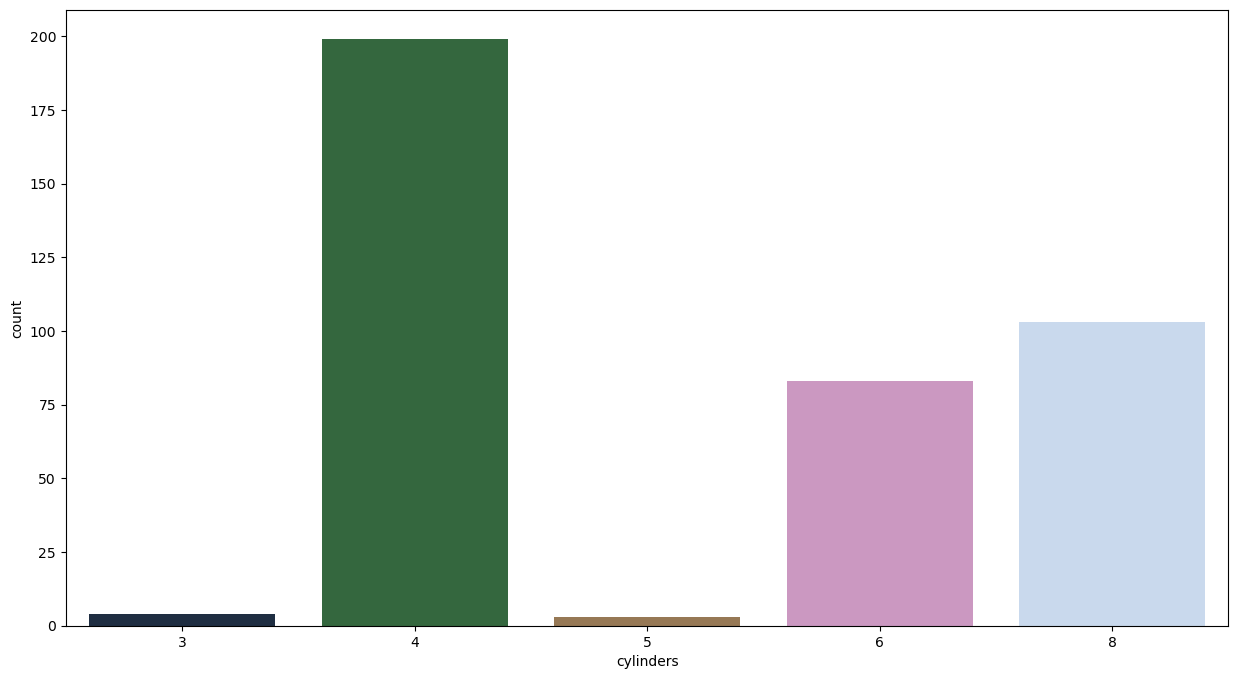

In [16]:
plt.figure(figsize=(15,8))
sns.countplot(x="cylinders", data=df, palette="cubehelix")  
plt.show()

In [17]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [18]:
df["model_year"] = (1900 + df.model_year)

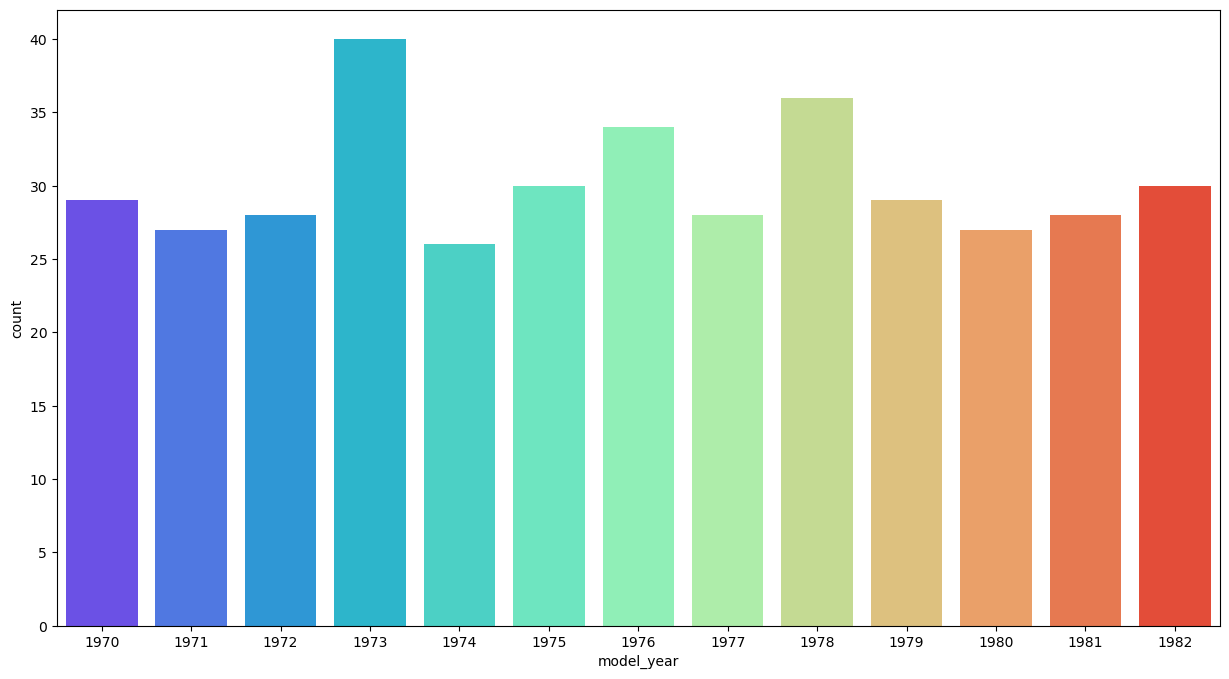

In [19]:
plt.figure(figsize=(15,8))
sns.countplot(x="model_year", data=df, palette="rainbow")  
plt.show()

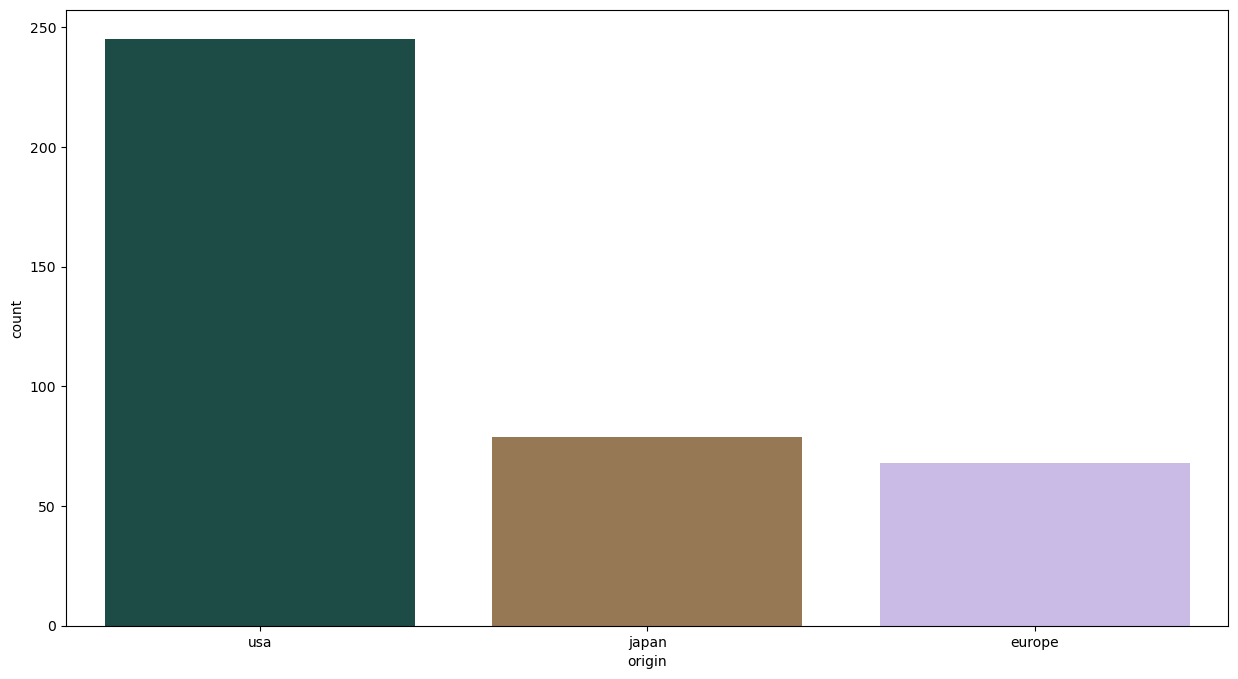

In [20]:
plt.figure(figsize=(15,8))
sns.countplot(x="origin", data=df, palette="cubehelix")  
plt.show()

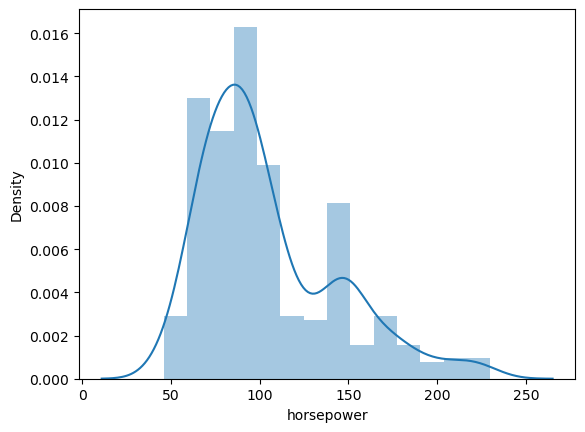

In [21]:
sns.distplot(df["horsepower"])
plt.show()

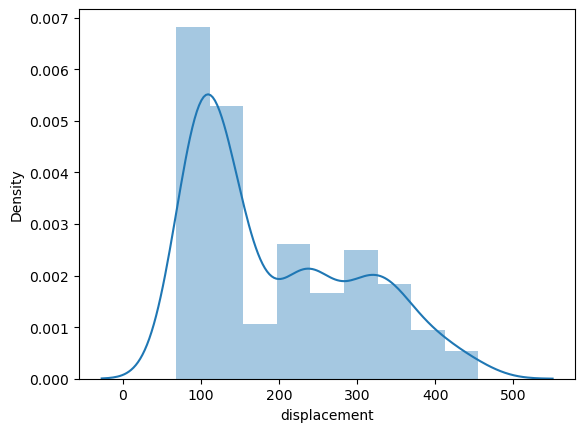

In [22]:
sns.distplot(df["displacement"])
plt.show()

**Двухмерный анализ**

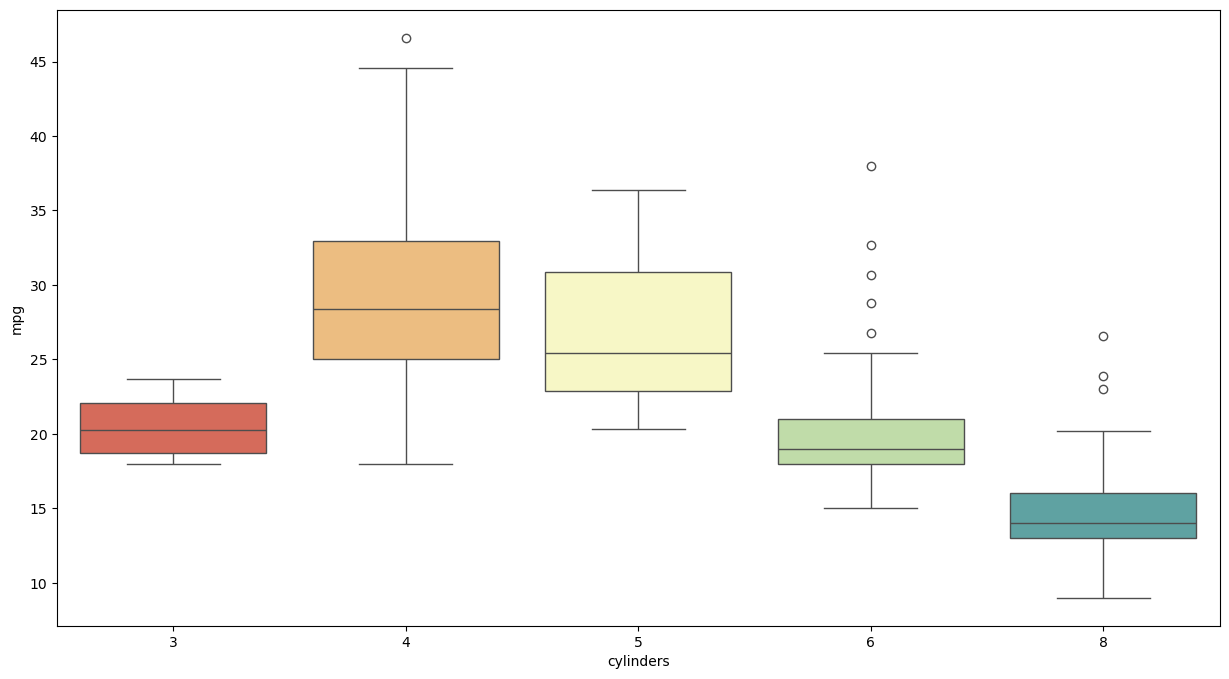

In [23]:
plt.figure(figsize=(15,8))
sns.boxplot(x="cylinders", y = "mpg", data=df, palette="Spectral")  
plt.show()

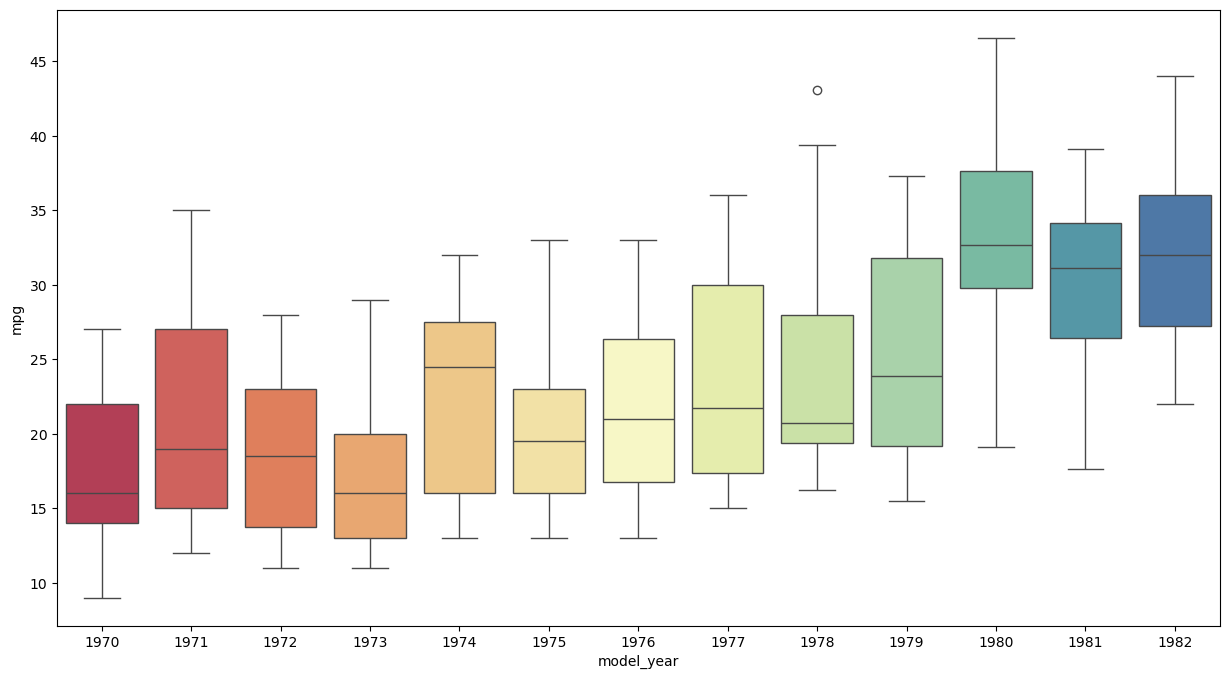

In [24]:
plt.figure(figsize=(15,8))
sns.boxplot(x="model_year", y = "mpg", data=df, palette="Spectral")  
plt.show()

**Многомерный анализ**

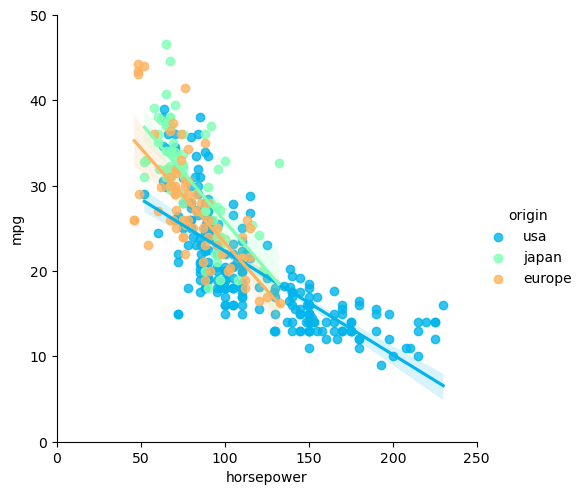

In [25]:
graph = sns.lmplot(x = "horsepower", y = "mpg", hue = "origin", data = df, palette = "rainbow")
graph.set(xlim = (0, 250))
graph.set(ylim = (0, 50))
plt.show()

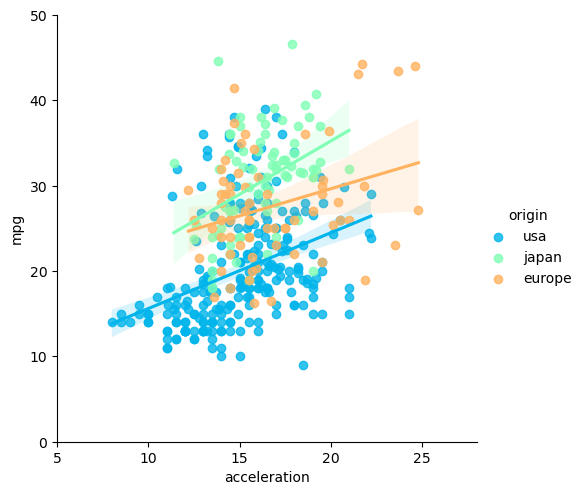

In [26]:
graph = sns.lmplot(x = "acceleration", y = "mpg", hue = "origin", data = df, palette = "rainbow")
graph.set(ylim = (0, 50))
graph.set(xlim = (5, 28))
plt.show()

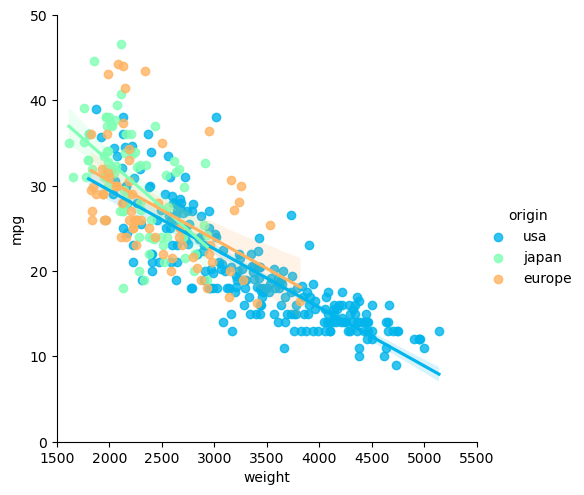

In [27]:
graph = sns.lmplot(x = "weight", y = "mpg", hue = "origin", data = df, palette = "rainbow")
graph.set(ylim = (0, 50))
graph.set(xlim = (1500, 5500))
plt.show()

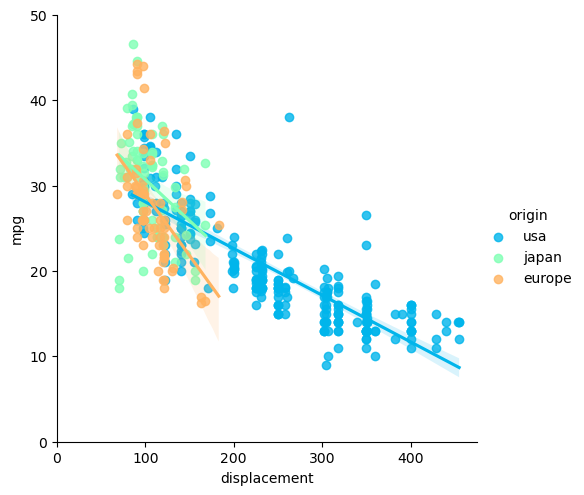

In [28]:
graph = sns.lmplot(x = "displacement", y = "mpg", hue = "origin", data = df, palette = "rainbow")
graph.set(ylim = (0, 50))
graph.set(xlim = (0, 475))
plt.show()

**Тепловая карта (heatmap) корреляции матрицы**

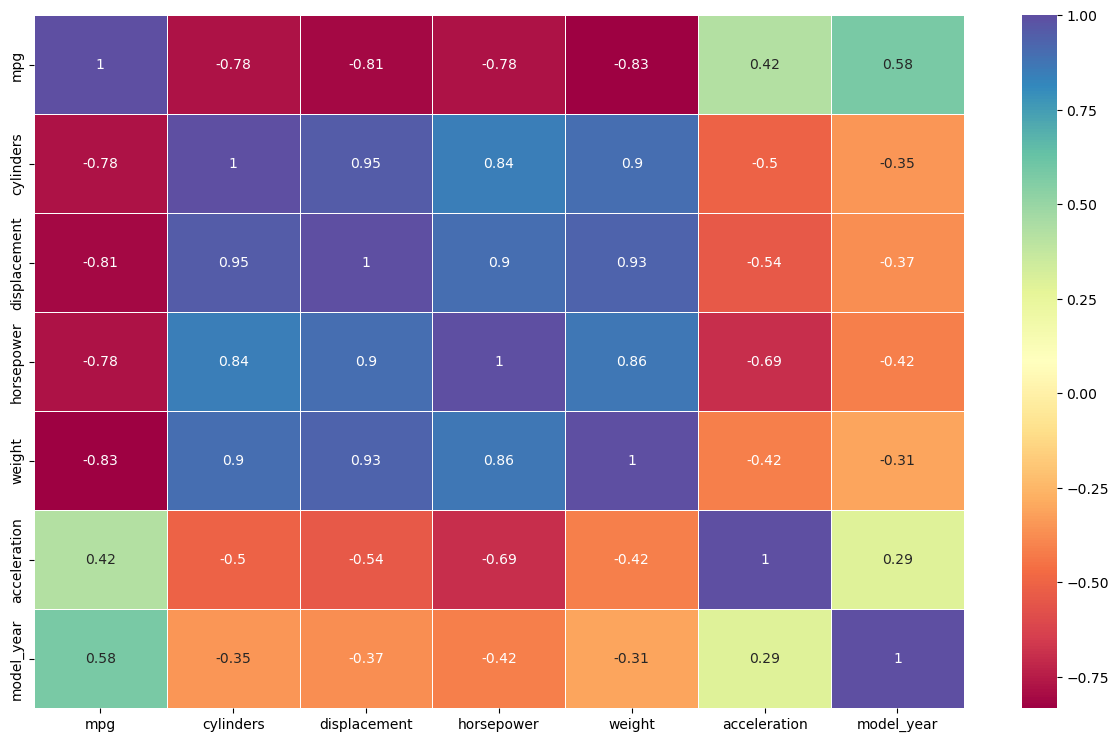

In [29]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(15,9))
sns.heatmap(numeric_df.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")  
plt.show()

**Подготовка данных для моделирования**

Преобразуем категориальный признак origin с помощью One-Hot Encoding и разделяем данные на обучающую и тестовую выборки (обычно 80/20 или 75/25).
Масштабируем числовые признаки (StandardScaler или MinMaxScaler) — важный шаг для линейной регрессии

In [30]:
df.drop(["acceleration", "displacement"], axis = 1, inplace = True)

In [31]:
df.head()

,mpg,cylinders,horsepower,weight,model_year,origin
0,18.0,8,130.0,3504,1970,usa
1,15.0,8,165.0,3693,1970,usa
2,18.0,8,150.0,3436,1970,usa
3,16.0,8,150.0,3433,1970,usa
4,17.0,8,140.0,3449,1970,usa


In [32]:
from datetime import datetime

In [33]:
today = datetime.today()

In [34]:
today

datetime.datetime(2026, 4, 3, 12, 25, 36, 743776)

In [35]:
this_year = today.year
this_year

2026

In [36]:
df["age"] = this_year -df.model_year

In [37]:
df.drop(["model_year"], axis = 1, inplace = True)

In [38]:
df.head()

,mpg,cylinders,horsepower,weight,origin,age
0,18.0,8,130.0,3504,usa,56
1,15.0,8,165.0,3693,usa,56
2,18.0,8,150.0,3436,usa,56
3,16.0,8,150.0,3433,usa,56
4,17.0,8,140.0,3449,usa,56


In [39]:
df.origin.unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [40]:
df = pd.get_dummies(df, drop_first = True)

In [41]:
df.head()

,mpg,cylinders,horsepower,weight,age,origin_japan,origin_usa
0,18.0,8,130.0,3504,56,False,True
1,15.0,8,165.0,3693,56,False,True
2,18.0,8,150.0,3436,56,False,True
3,16.0,8,150.0,3433,56,False,True
4,17.0,8,140.0,3449,56,False,True


**Построение и обучение модели Linear Regression**

Обучаем базовую модель линейной регрессии для предсказания расхода топлива (mpg). Линейная регрессия выбрана как интерпретируемая и хорошо подходящая для данной задачи модель первого уровня.

In [42]:
X = df.drop(["mpg"], axis = 1)
y = df["mpg"]

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [45]:
X_train

,cylinders,horsepower,weight,age,origin_japan,origin_usa
260,6,110.0,3620,48,False,True
184,4,92.0,2572,50,False,True
174,6,97.0,2984,51,False,True
64,8,150.0,4135,54,False,True
344,4,64.0,1875,45,False,True
...,...,...,...,...,...,...
72,8,150.0,3892,54,False,True
107,6,100.0,2789,53,False,True
272,4,85.0,2855,48,False,True
352,4,65.0,2380,45,False,True


In [46]:
y_train

260    18.6
184    25.0
174    18.0
64     15.0
344    39.0
       ... 
72     15.0
107    18.0
272    23.8
352    29.9
103    11.0
Name: mpg, Length: 313, dtype: float64

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
lm_model = LinearRegression()

In [49]:
lm_model.fit(X_train, y_train)

LinearRegression()

In [50]:
lm_model.intercept_

np.float64(81.36422963606499)

In [51]:
coef_param = pd.DataFrame(lm_model.coef_, index = X.columns, columns = ["Coefficient"])
coef_param

,Coefficient
cylinders,0.203056
horsepower,-0.014143
weight,-0.005729
age,-0.779904
origin_japan,0.401853
origin_usa,-2.385047


In [52]:
y_pred = lm_model.predict(X_test)

In [53]:
my_dict = {"Actual" : y_test, "Pred" : y_pred}
compare = pd.DataFrame(my_dict)

In [54]:
compare.sample(10)

,Actual,Pred
5,15.0,9.259506
25,10.0,7.449357
307,26.8,26.447530
134,16.0,17.279368
43,13.0,8.115192
249,19.9,22.334720
91,13.0,11.573409
3,16.0,15.140213
358,31.6,31.340354
366,17.6,24.048994


In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [56]:
def evaluation_metrics(actual, pred):
    MAE = mean_absolute_error(actual, pred)
    MSE = mean_squared_error(actual, pred)
    RMSE = np.sqrt(mean_squared_error(actual, pred))
    SCORE = r2_score(actual, pred)
    return print("r2 score:", SCORE, "\n", "mae:", MAE, "\n", "mse:", MSE, "\n", "rmse:", RMSE)

In [57]:
evaluation_metrics(y_test, y_pred)

r2 score: 0.7798249880881909 
 mae: 2.5188281576150895 
 mse: 11.237861022823049 
 rmse: 3.3522919059686687


Высокое значение R² (обычно 0.75–0.85 в подобных проектах) говорит о том, что модель хорошо объясняет вариацию целевой переменной.
Анализ остатков позволяет проверить выполнение основных предположений линейной регрессии (линейность, гомоскедастичность, отсутствие автокорреляции).

In [58]:
from sklearn.model_selection import cross_val_score

In [59]:
accuracies = cross_val_score(estimator = lm_model, X = X_train, y = y_train, cv=10)

In [60]:
accuracies

array([0.83385985, 0.8017547 , 0.83571526, 0.79337835, 0.74392253,
       0.78022115, 0.85414984, 0.76313671, 0.81547906, 0.88691579])

In [61]:
accuracies.mean()

np.float64(0.8108533245510495)

In [62]:
accuracies = cross_val_score(estimator = lm_model, X = X_train, y = y_train, cv=10, scoring = "neg_mean_squared_error")

In [63]:
accuracies.mean()

np.float64(-11.790387919443372)

In [64]:
-accuracies.mean()

np.float64(11.790387919443372)

Изучаем коэффициенты линейной регрессии, чтобы понять влияние каждого признака на расход топлива:

Отрицательные коэффициенты у weight, horsepower, displacement — чем тяжелее и мощнее автомобиль, тем выше расход топлива (ниже mpg) Положительный эффект у model_year — автомобили более поздних годов выпуска, как правило, экономичнее Автомобили японского и европейского производства (origin) в среднем имеют более низкий расход топлива по сравнению с американскими

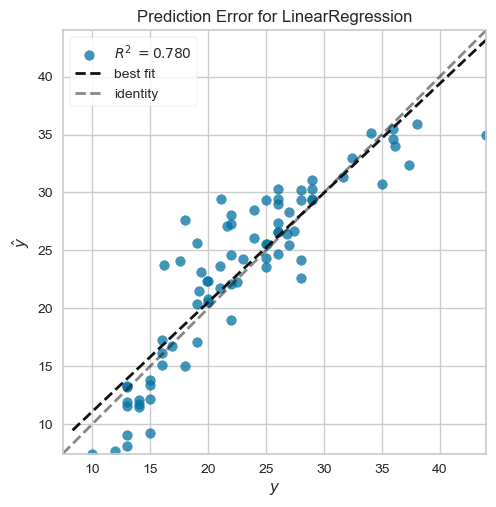

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [65]:
from yellowbrick.regressor import PredictionError

visualizer = PredictionError(lm_model)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)

visualizer.show()

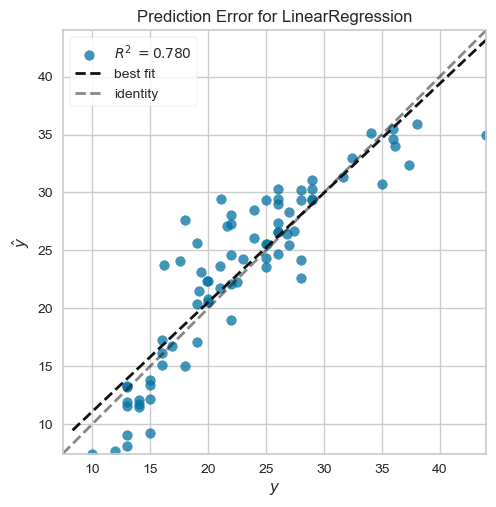

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [66]:
from yellowbrick.regressor import ResidualsPlot

visualizer = PredictionError(lm_model)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)

visualizer.show()

**Выводы и итог**

Основные выводы проекта:

Линейная регрессия показала хорошее качество предсказания расхода топлива на данном датасете.
Наиболее значимыми предикторами являются вес автомобиля (weight), мощность (horsepower) и год выпуска (model_year).
Страна-производитель (origin) оказывает заметное влияние даже после учёта технических характеристик.
Модель достаточно хорошо интерпретируема, что важно для понимания бизнес/технических факторов экономичности автомобилей.

Общий итог:
Проект демонстрирует полный цикл работы специалиста по Data Science: от понимания предметной области и качественного EDA до построения, оценки и интерпретации линейной модели. Полученные результаты подтверждают сильную зависимость расхода топлива от технических характеристик автомобиля и позволяют делать обоснованные выводы о факторах, влияющих на топливную экономичность.